<a href="https://colab.research.google.com/github/nchoudha4-beep/Kiran-steels-/blob/main/Perceptron_AND_Gate_with_hard_coded_weights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Weight : w1 = 1.0   w2 = 1.0
Bias   : b = -1.5
Equation: 1.0*X1 + 1.0*X2 + -1.5 > 0

prediction:
[0, 0] -> Linear : -1.5 -> pred: 0 | Actual : 0
[0, 1] -> Linear : -0.5 -> pred: 0 | Actual : 0
[1, 0] -> Linear : -0.5 -> pred: 0 | Actual : 0
[1, 1] -> Linear :  0.5 -> pred: 1 | Actual : 1


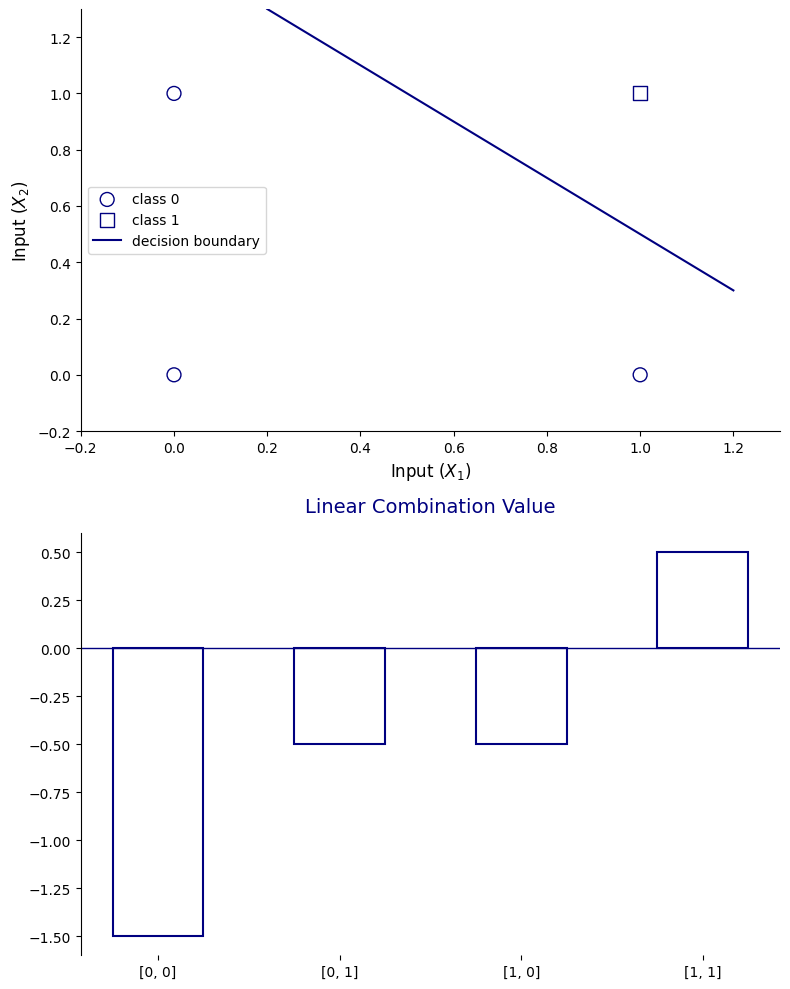

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. PERCEPTRON LOGIC & TEXT OUTPUT
# ==========================================

# Define Input (X) and Actual Output (Y) for an AND gate
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y = np.array([[0], [0], [0], [1]])

# Hardcode Weights and Bias
weights = np.array([[1.0], [1.0]])
bias = np.array([[-1.5]])

# Define the Step Function (Activation)
def step_function(x):
    return 1 if x > 0 else 0

# Define the Perceptron Prediction Function
def perceptron_predict(X, weights, bias):
    # Calculate the linear combination (dot product)
    linear = np.dot(X, weights) + bias
    # Initialize an array of zeros for predictions
    predictions = np.zeros((len(X), 1))

    # Apply the step function to each linear value
    for i in range(len(linear)):
        predictions[i, 0] = step_function(linear[i, 0])

    return predictions, linear

# Execute Prediction
predictions, linear_values = perceptron_predict(X, weights, bias)

# Print Output
print(f"Weight : w1 = {weights[0,0]:.1f}   w2 = {weights[1,0]:.1f}")
print(f"Bias   : b = {bias[0,0]:.1f}")
print(f"Equation: {weights[0,0]:.1f}*X1 + {weights[1,0]:.1f}*X2 + {bias[0,0]:.1f} > 0\n")
print("prediction:")

for i in range(len(X)):
    linear_val = linear_values[i, 0]
    pred = int(predictions[i, 0])
    actual = int(Y[i, 0])
    print(f"[{X[i,0]}, {X[i,1]}] -> Linear : {linear_val:>4.1f} -> pred: {pred} | Actual : {actual}")


# ==========================================
# 2. GENERATING THE CHARTS
# ==========================================

# Create a figure with two subplots (2 rows, 1 column)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))

# --- Top Chart: Scatter Plot & Decision Boundary ---
# Separate the points by class for plotting
class_0_x1, class_0_x2 = [0, 0, 1], [0, 1, 0]
class_1_x1, class_1_x2 = [1], [1]

# Plot Class 0 (Circles) and Class 1 (Square)
ax1.scatter(class_0_x1, class_0_x2, color='navy', marker='o', s=100, facecolors='none', label='class 0')
ax1.scatter(class_1_x1, class_1_x2, color='navy', marker='s', s=100, facecolors='none', label='class 1')

# Draw the decision boundary: 1.0*X1 + 1.0*X2 - 1.5 = 0  =>  X2 = 1.5 - X1
x1_line = np.linspace(0.2, 1.2, 10)
x2_line = 1.5 - x1_line
ax1.plot(x1_line, x2_line, color='navy', linestyle='-', label='decision boundary')

# Formatting the top chart
ax1.set_xlim(-0.2, 1.3)
ax1.set_ylim(-0.2, 1.3)
ax1.set_xticks(np.arange(-0.2, 1.4, 0.2))
ax1.set_yticks(np.arange(-0.2, 1.4, 0.2))
ax1.set_xlabel('Input ($X_1$)', fontsize=12)
ax1.set_ylabel('Input ($X_2$)', fontsize=12)
ax1.legend(loc='center left')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Bottom Chart: Linear Combination Bar Chart ---
labels = ['[0, 0]', '[0, 1]', '[1, 0]', '[1, 1]']
# Flatten linear_values array for the bar chart
flat_linear_values = linear_values.flatten()

# Draw the bars
bars = ax2.bar(labels, flat_linear_values, width=0.5, color='none', edgecolor='navy', linewidth=1.5)

# Add a horizontal line at y=0
ax2.axhline(0, color='navy', linewidth=1)

# Formatting the bottom chart
ax2.set_title('Linear Combination Value', fontsize=14, color='navy', pad=15)
ax2.set_ylim(-1.6, 0.6)
ax2.set_yticks(np.arange(-1.50, 0.75, 0.25))
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()